# Correlation Analysis: Hardness, Plastic Zone Area, and Phase Ratios

Analyze the correlation between `hardness_value`, `plastic_zone_area`, `light_phase_ratio`, and `dark_phase_ratio` from the IM2PROP dataset.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load and Explore the CSV Data

In [3]:
df = pd.read_csv("IM2PROP_data/IM2PROP_dataset_homo_ratio_v1.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (24, 5)


,image_id,hardness_value,plastic_zone_area,light_phase_ratio,dark_phase_ratio
0,HO_1,2.4119,46473.315,54.845679,45.154321
1,HO_2,2.6306,42609.206,54.580440,45.419560
2,HO_3,2.5591,43799.160,60.456597,39.543403
3,HO_4,2.6550,42217.896,64.235340,35.764660
4,HO_5,2.9240,38333.947,69.956983,30.043017
5,HO_6,3.1043,36107.395,72.691165,27.308835
6,HO_7,2.5712,43593.158,63.475694,36.524306
7,HO_8,2.7027,41473.172,65.740548,34.259452
8,HO_9,2.3057,48614.151,68.573688,31.426312
9,HO_10,2.3866,46965.894,77.016397,22.983603


In [4]:
df.info()
print("\n")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   image_id           24 non-null     str    
 1   hardness_value     24 non-null     float64
 2   plastic_zone_area  24 non-null     float64
 3   light_phase_ratio  24 non-null     float64
 4   dark_phase_ratio   24 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.1 KB




,hardness_value,plastic_zone_area,light_phase_ratio,dark_phase_ratio
count,24.000000,24.000000,24.000000,24.000000
mean,2.493425,45196.154333,64.749727,35.250273
std,0.197445,3211.610340,10.398649,10.398649
min,2.301300,36107.395000,37.807292,21.540316
25%,2.371050,43747.659500,59.187982,27.055314
50%,2.419750,46322.083500,66.650463,33.349537
75%,2.562125,47273.470000,72.944686,40.812018
max,3.104300,48707.206000,78.459684,62.192708


## 3. Data Cleaning and Preprocessing

In [5]:
target_cols = ["hardness_value", "plastic_zone_area", "light_phase_ratio", "dark_phase_ratio"]

# Check for missing values
print("Missing values:")
print(df[target_cols].isnull().sum())

# Ensure numeric types
for col in target_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=target_cols, inplace=True)
print(f"\nRows after cleaning: {len(df)}")

Missing values:
hardness_value       0
plastic_zone_area    0
light_phase_ratio    0
dark_phase_ratio     0
dtype: int64

Rows after cleaning: 24


## 4. Select Target Columns

In [6]:
df_corr = df[target_cols].copy()
df_corr.head()

,hardness_value,plastic_zone_area,light_phase_ratio,dark_phase_ratio
0,2.4119,46473.315,54.845679,45.154321
1,2.6306,42609.206,54.580440,45.419560
2,2.5591,43799.160,60.456597,39.543403
3,2.6550,42217.896,64.235340,35.764660
4,2.9240,38333.947,69.956983,30.043017


## 5. Compute Correlation Matrices

Compute both **Pearson** (linear) and **Spearman** (rank-based) correlations.

In [7]:
pearson_corr = df_corr.corr(method="pearson")
spearman_corr = df_corr.corr(method="spearman")

print("=== Pearson Correlation ===")
print(pearson_corr.round(4))
print("\n=== Spearman Correlation ===")
print(spearman_corr.round(4))

=== Pearson Correlation ===
                   hardness_value  plastic_zone_area  light_phase_ratio  \
hardness_value             1.0000            -0.9956             0.1347   
plastic_zone_area         -0.9956             1.0000            -0.1204   
light_phase_ratio          0.1347            -0.1204             1.0000   
dark_phase_ratio          -0.1347             0.1204            -1.0000   

                   dark_phase_ratio  
hardness_value              -0.1347  
plastic_zone_area            0.1204  
light_phase_ratio           -1.0000  
dark_phase_ratio             1.0000  

=== Spearman Correlation ===
                   hardness_value  plastic_zone_area  light_phase_ratio  \
hardness_value             1.0000            -1.0000            -0.0574   
plastic_zone_area         -1.0000             1.0000             0.0574   
light_phase_ratio         -0.0574             0.0574             1.0000   
dark_phase_ratio           0.0574            -0.0574            -1.0000   



## 6. Correlation Heatmaps

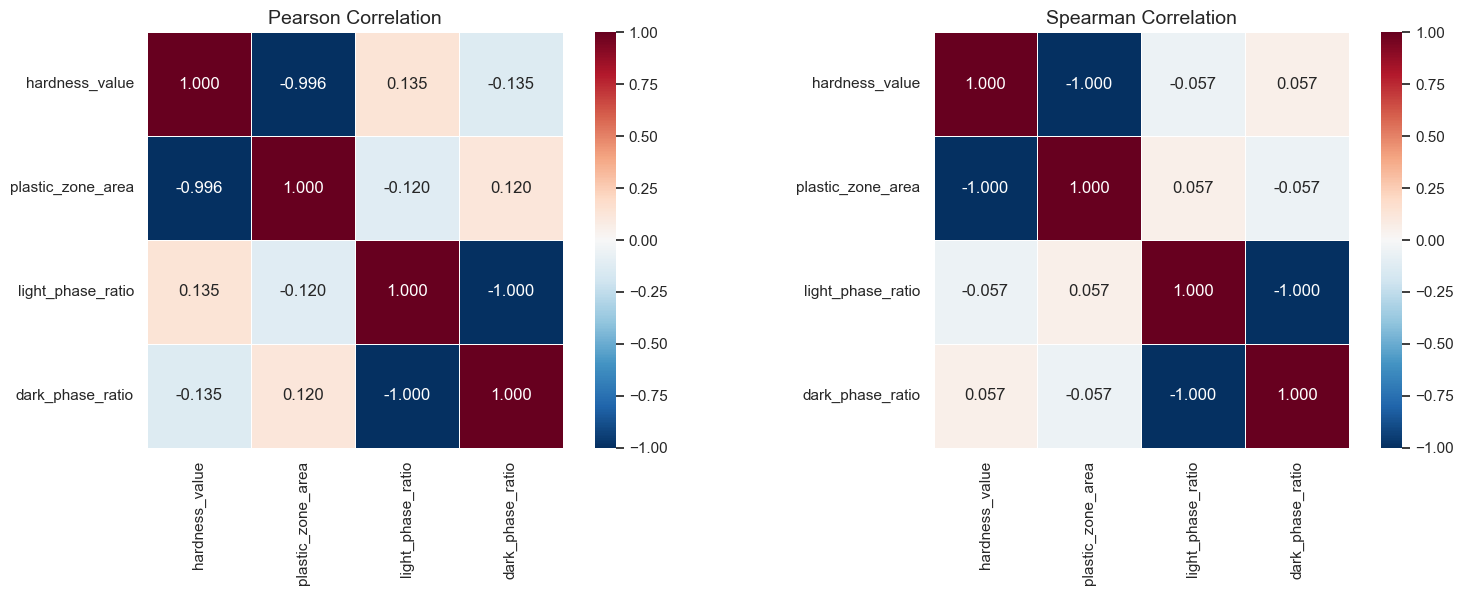

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Pearson Correlation", fontsize=14)

sns.heatmap(spearman_corr, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title("Spearman Correlation", fontsize=14)

plt.tight_layout()
plt.show()

## 7. Pairplot of Selected Variables

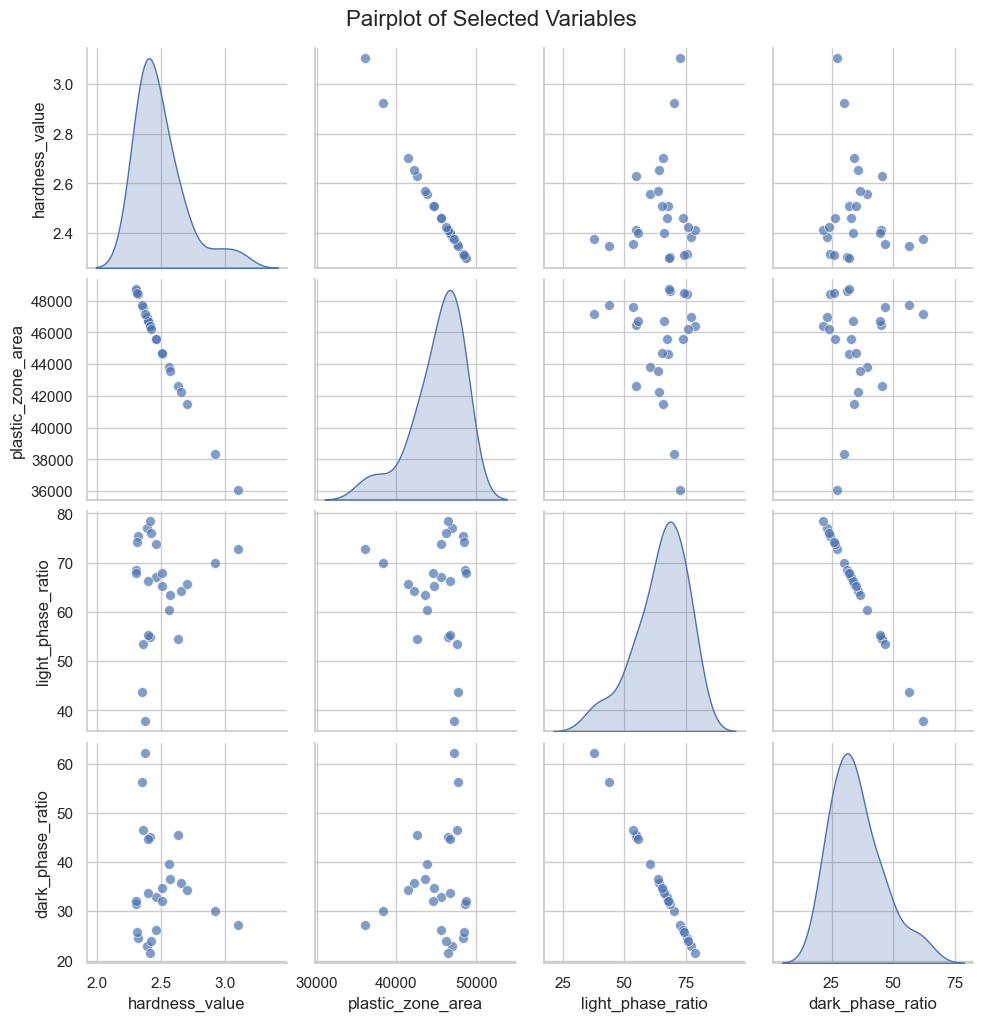

In [9]:
g = sns.pairplot(df_corr, diag_kind="kde", plot_kws={"alpha": 0.7, "s": 50})
g.figure.suptitle("Pairplot of Selected Variables", y=1.02, fontsize=16)
plt.show()

### Scatter Plots with Regression Lines

Focus on `hardness_value` vs. the other three variables.

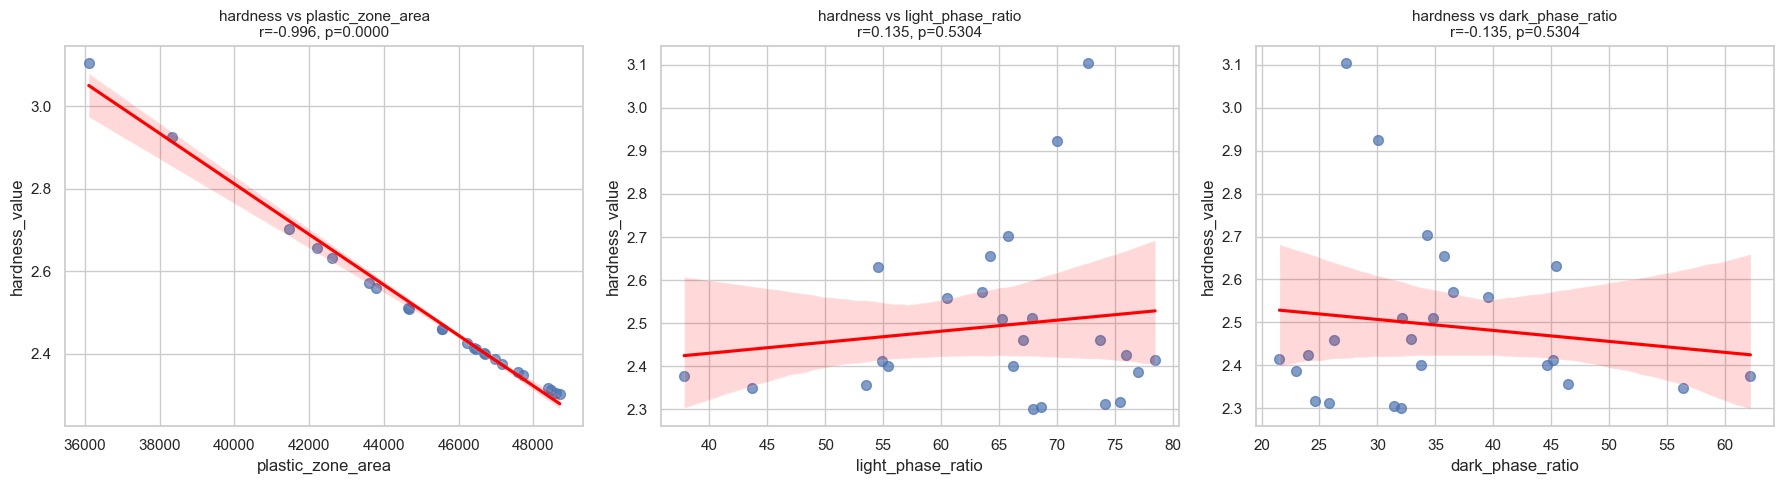

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

other_cols = ["plastic_zone_area", "light_phase_ratio", "dark_phase_ratio"]
for ax, col in zip(axes, other_cols):
    sns.regplot(data=df_corr, x=col, y="hardness_value", ax=ax,
                scatter_kws={"alpha": 0.7, "s": 50}, line_kws={"color": "red"})
    r, p = stats.pearsonr(df_corr[col], df_corr["hardness_value"])
    ax.set_title(f"hardness vs {col}\nr={r:.3f}, p={p:.4f}", fontsize=11)

plt.tight_layout()
plt.show()

## 8. Statistical Significance Testing

Compute Pearson and Spearman correlation coefficients with p-values for every variable pair.

In [11]:
results = []
for col_a, col_b in combinations(target_cols, 2):
    pr, pp = stats.pearsonr(df_corr[col_a], df_corr[col_b])
    sr, sp = stats.spearmanr(df_corr[col_a], df_corr[col_b])
    results.append({
        "Variable 1": col_a,
        "Variable 2": col_b,
        "Pearson r": round(pr, 4),
        "Pearson p-value": round(pp, 6),
        "Pearson Significant (p<0.05)": pp < 0.05,
        "Spearman r": round(sr, 4),
        "Spearman p-value": round(sp, 6),
        "Spearman Significant (p<0.05)": sp < 0.05,
    })

df_results = pd.DataFrame(results)
df_results

,Variable 1,Variable 2,Pearson r,Pearson p-value,Pearson Significant (p<0.05),Spearman r,Spearman p-value,Spearman Significant (p<0.05)
0,hardness_value,plastic_zone_area,-0.9956,0.000000,True,-1.0000,0.000000,True
1,hardness_value,light_phase_ratio,0.1347,0.530410,False,-0.0574,0.789955,False
2,hardness_value,dark_phase_ratio,-0.1347,0.530410,False,0.0574,0.789955,False
3,plastic_zone_area,light_phase_ratio,-0.1204,0.575348,False,0.0574,0.789955,False
4,plastic_zone_area,dark_phase_ratio,0.1204,0.575348,False,-0.0574,0.789955,False
5,light_phase_ratio,dark_phase_ratio,-1.0000,0.000000,True,-1.0000,0.000000,True
